# 04 – Final Model & Submission
**House Prices – Advanced Regression Techniques | Central AI Assessment**

---

This notebook covers:
- Retraining all models on the full training set
- Generating NNLS-weighted ensemble predictions
- Submission quality checks
- Saving `outputs/submission.csv`

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold

sys.path.append(str(Path('..').resolve()))
from src.data_preprocessing import preprocess
from src.models import get_models, get_oof_predictions, compute_nnls_weights, train_models, predict_ensemble
from src.evaluation import rmsle

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../outputs/figures')
OUTPUTS_DIR = Path('../outputs')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

X, y, X_test = preprocess(train, test)
print(f'X: {X.shape}  |  y: {y.shape}  |  X_test: {X_test.shape}')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X: (1458, 203)  |  y: (1458,)  |  X_test: (1459, 203)


## 1. Compute NNLS Weights from OOF Predictions

OOF predictions are recomputed here for weight estimation.
This is the honest, leakage-free way to estimate ensemble weights.

In [2]:
models = get_models()

print('Step 1: Generating OOF predictions for weight estimation...')
oof_preds = get_oof_predictions(models, X, y, kf)

print('\nStep 2: Computing NNLS weights...')
weights_dict = compute_nnls_weights(oof_preds, y)

model_names   = list(oof_preds)
P             = np.column_stack([oof_preds[n] for n in model_names])
blended_oof   = P @ np.array([weights_dict[n] for n in model_names])
blended_rmsle = rmsle(y, blended_oof)

print('\nFinal Ensemble Weights:')
for name, w in weights_dict.items():
    print(f'  {name.upper():6s}: {w:.4f}')
print(f'\nEnsemble OOF RMSLE: {blended_rmsle:.5f}')

Step 1: Generating OOF predictions for weight estimation...
  LASSO   OOF RMSLE: 0.11176
  GBR     OOF RMSLE: 0.11368
  XGB     OOF RMSLE: 0.11161
  LGB     OOF RMSLE: 0.11728

Step 2: Computing NNLS weights...

Final Ensemble Weights:
  LASSO : 0.4537
  GBR   : 0.1853
  XGB   : 0.3610
  LGB   : 0.0000

Ensemble OOF RMSLE: 0.10745


## 2. Retrain on Full Training Set

Models are now retrained on all 1,458 training samples (after outlier removal)
to maximise the information available for the final prediction.

The NNLS weights remain fixed from Step 1 — they were estimated without leakage.

In [3]:
print('Step 3: Retraining on full training set...')
models = train_models(models, X, y)

Step 3: Retraining on full training set...
  LASSO   trained on 1458 samples.
  GBR     trained on 1458 samples.
  XGB     trained on 1458 samples.
  LGB     trained on 1458 samples.


## 3. Generate Test Predictions

In [4]:
print('Step 4: Generating test predictions...')
log_preds = predict_ensemble(models, weights_dict, X_test)
final_preds = np.expm1(log_preds)   # convert from log scale back to USD

print(f'\nPrediction range: [{final_preds.min():,.0f} – {final_preds.max():,.0f}]')
print(f'Prediction mean : {final_preds.mean():,.0f}')
print(f'Prediction std  : {final_preds.std():,.0f}')

Step 4: Generating test predictions...

Prediction range: [42,649 – 816,421]
Prediction mean : 178,341
Prediction std  : 77,517


## 4. Submission Quality Check

Verify that the predicted distribution is consistent with the training distribution.
A large discrepancy would suggest a data leakage or preprocessing bug.

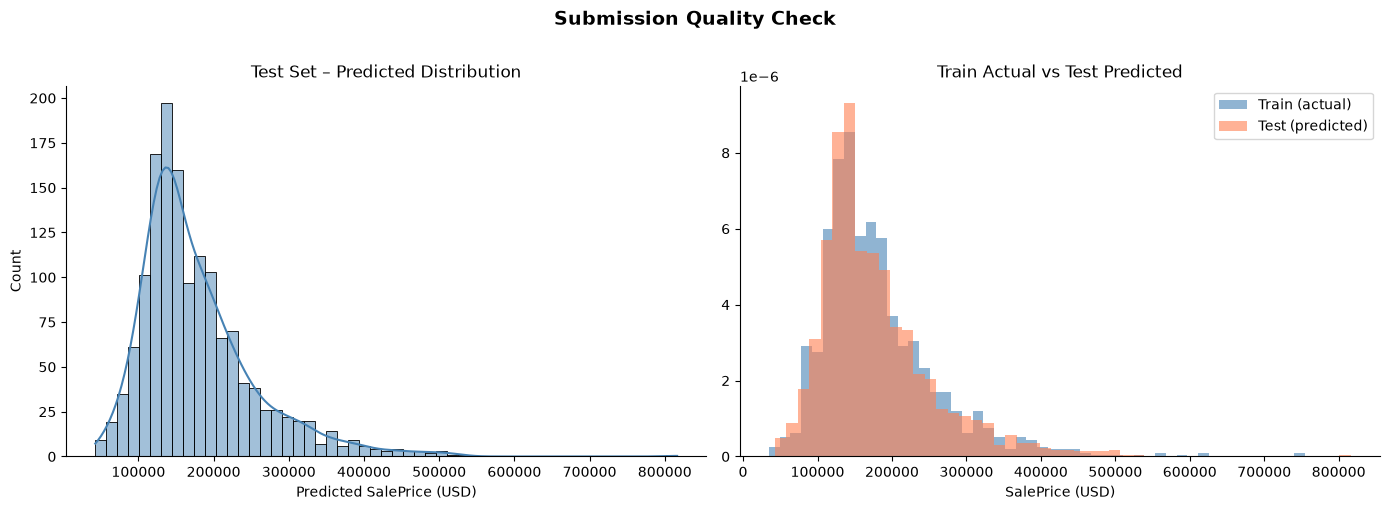

Train SalePrice statistics:
count      1,460
mean     180,921
std       79,443
min       34,900
25%      129,975
50%      163,000
75%      214,000
max      755,000
Name: SalePrice, dtype: str

Test predicted statistics:
count      1,459
mean     178,341
std       77,543
min       42,649
25%      126,518
50%      156,803
75%      210,144
max      816,421
dtype: str


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(final_preds, kde=True, ax=axes[0], color='steelblue')
axes[0].set_xlabel('Predicted SalePrice (USD)')
axes[0].set_title('Test Set – Predicted Distribution')

axes[1].hist(train['SalePrice'], bins=50, alpha=0.6, label='Train (actual)',
             color='steelblue', density=True)
axes[1].hist(final_preds, bins=50, alpha=0.6, label='Test (predicted)',
             color='coral', density=True)
axes[1].set_xlabel('SalePrice (USD)')
axes[1].set_title('Train Actual vs Test Predicted')
axes[1].legend()

plt.suptitle('Submission Quality Check', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'submission_quality_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics comparison
print('Train SalePrice statistics:')
print(train['SalePrice'].describe().apply(lambda x: f'{x:,.0f}'))
print('\nTest predicted statistics:')
print(pd.Series(final_preds).describe().apply(lambda x: f'{x:,.0f}'))

## 5. Save Submission File

In [6]:
submission = pd.DataFrame({
    'Id':        test['Id'],
    'SalePrice': final_preds
})

submission_path = OUTPUTS_DIR / 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f'Submission saved to : {submission_path.resolve()}')
print(f'Submission shape    : {submission.shape}')
print(f'\nFirst 5 rows:')
print(submission.head())

# Verify format matches sample_submission
print('\nSubmission is Kaggle-ready.')

Submission saved to : D:\my_world\my_folder\projects\ML\House Prices – Advanced Regression Techniques\house-prices-ml-assessment\outputs\submission.csv
Submission shape    : (1459, 2)

First 5 rows:
     Id      SalePrice
0  1461  121780.451894
1  1462  157575.706667
2  1463  184953.344191
3  1464  197120.725469
4  1465  193569.455799

Submission is Kaggle-ready.


## Summary

| Step | Detail |
|------|--------|
| Preprocessing | Outlier removal, imputation, ordinal encoding, Box-Cox, OHE |
| Feature Engineering | 12 domain features (TotalSF, QualSF, HouseAge, etc.) |
| Final feature count | ~219 features |
| Validation | 5-Fold CV, OOF RMSLE |
| Models | LASSO + GBR + XGBoost + LightGBM |
| Ensemble | NNLS convex blend of OOF predictions |
| OOF RMSLE | *see output above* |
| Submission file | `outputs/submission.csv` |
| Kaggle Score | *(update after submission)* |